In [4]:
import pandas as pd
import os

folder = r"C:\Users\HP\Desktop\internship\Project4_Ag_Prediction of Agriculture Crop Production In India\Project4_Ag_Prediction of Agriculture Crop Production In India"

files = ["datafile (1).csv", "datafile (2).csv",
         "datafile (3).csv", "datafile.csv", "produce.csv"]

for f in files:
    path = os.path.join(folder, f)
    try:
        df = pd.read_csv(path, encoding='latin1')
        print(f"\n {f}")
        print(f"   Shape   : {df.shape}")
        print(f"   Columns : {list(df.columns)}")
        print(df.head(2))
        print("-"*60)
    except Exception as e:
        print(f" Error: {f} → {e}")


 datafile (1).csv
   Shape   : (49, 6)
   Columns : ['Crop', 'State', 'Cost of Cultivation (`/Hectare) A2+FL', 'Cost of Cultivation (`/Hectare) C2', 'Cost of Production (`/Quintal) C2', 'Yield (Quintal/ Hectare) ']
    Crop          State  Cost of Cultivation (`/Hectare) A2+FL  \
0  ARHAR  Uttar Pradesh                                9794.05   
1  ARHAR      Karnataka                               10593.15   

   Cost of Cultivation (`/Hectare) C2  Cost of Production (`/Quintal) C2  \
0                            23076.74                            1941.55   
1                            16528.68                            2172.46   

   Yield (Quintal/ Hectare)   
0                       9.83  
1                       7.47  
------------------------------------------------------------

 datafile (2).csv
   Shape   : (55, 16)
   Columns : ['Crop             ', 'Production 2006-07', 'Production 2007-08', 'Production 2008-09', 'Production 2009-10', 'Production 2010-11', 'Area 2006-07', 

In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported!")

 All libraries imported!


In [6]:
older = r"C:\Users\HP\Desktop\internship\Project4_Ag_Prediction of Agriculture Crop Production In India"

df1 = pd.read_csv(folder + r"\datafile (1).csv", encoding='latin1')
df2 = pd.read_csv(folder + r"\datafile (2).csv", encoding='latin1')
df3 = pd.read_csv(folder + r"\datafile (3).csv", encoding='latin1')
df4 = pd.read_csv(folder + r"\datafile.csv",     encoding='latin1')
df5 = pd.read_csv(folder + r"\produce.csv",      encoding='latin1')

# Clean column names
for df in [df1, df2, df3, df4, df5]:
    df.columns = df.columns.str.strip()

print(" All files loaded!")
print(f"   df1 (Cost+Yield)     : {df1.shape}")
print(f"   df2 (Production)     : {df2.shape}")
print(f"   df3 (Crop Variety)   : {df3.shape}")
print(f"   df4 (Year Index)     : {df4.shape}")
print(f"   df5 (Annual Produce) : {df5.shape}")

 All files loaded!
   df1 (Cost+Yield)     : (49, 6)
   df2 (Production)     : (55, 16)
   df3 (Crop Variety)   : (78, 5)
   df4 (Year Index)     : (13, 9)
   df5 (Annual Produce) : (429, 25)


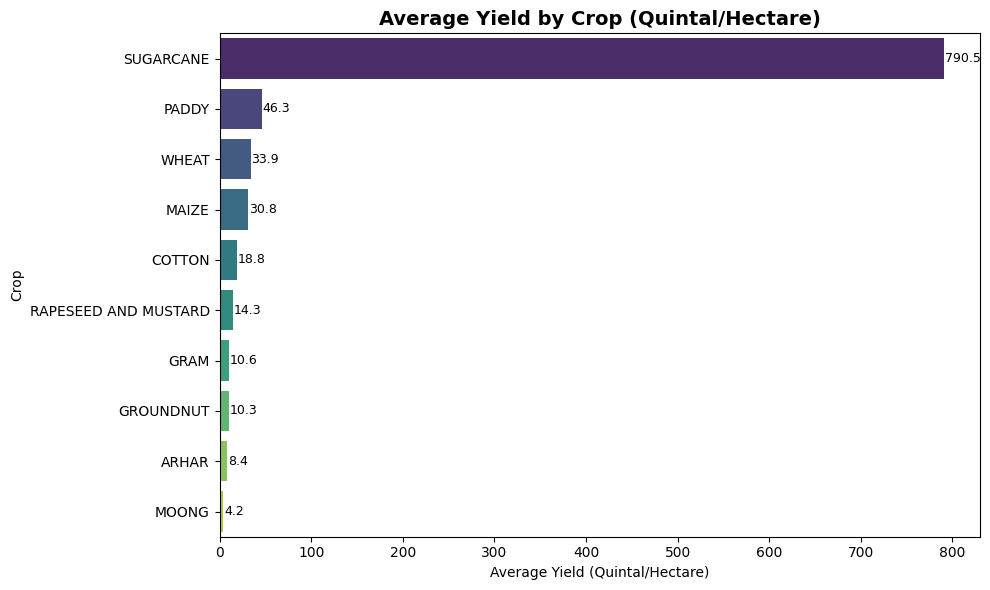

In [7]:


###  Plot 1: Top Crops by Yield

plt.figure(figsize=(10, 6))

# Use mean yield per crop (handles duplicates better)
crop_yield = df1.groupby('Crop')['Yield (Quintal/ Hectare)']\
               .mean().sort_values(ascending=False).reset_index()

sns.barplot(x='Yield (Quintal/ Hectare)', 
            y='Crop',
            data=crop_yield,
            palette='viridis')

#  value labels on each bar
for i, val in enumerate(crop_yield['Yield (Quintal/ Hectare)']):
    plt.text(val + 1, i, f'{val:.1f}', va='center', fontsize=9)

plt.title('Average Yield by Crop (Quintal/Hectare)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Average Yield (Quintal/Hectare)')
plt.ylabel('Crop')
plt.tight_layout()
plt.savefig('plot1_yield.png', dpi=150)
plt.show()


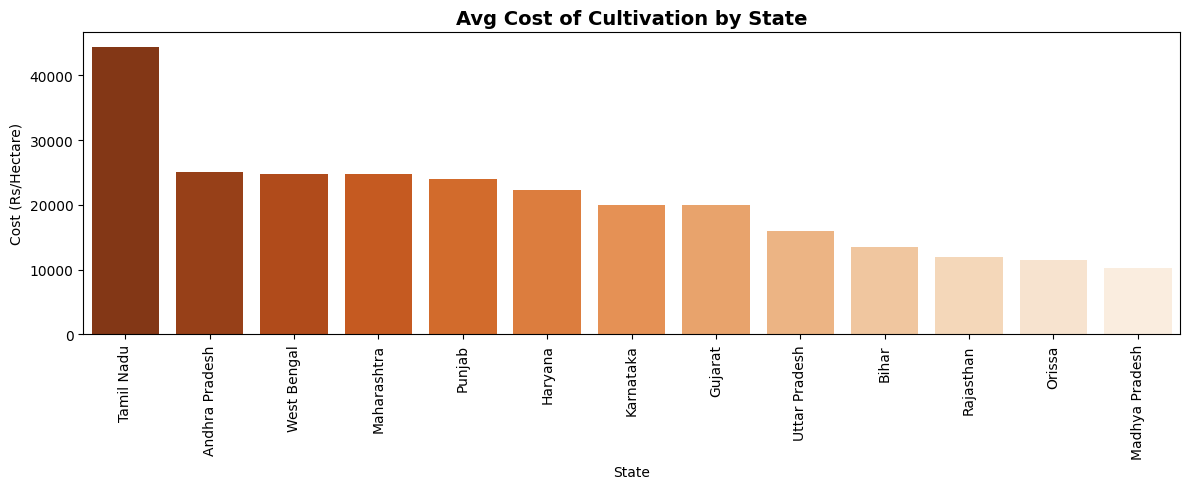

In [8]:
### Cell 3B — Plot 2: Cost by State

plt.figure(figsize=(12, 5))
state_cost = df1.groupby('State')['Cost of Cultivation (`/Hectare) A2+FL']\
               .mean().sort_values(ascending=False).reset_index()

sns.barplot(x='State', 
            y='Cost of Cultivation (`/Hectare) A2+FL',
            data=state_cost,
            palette='Oranges_r')
plt.title('Avg Cost of Cultivation by State', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Cost (Rs/Hectare)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('plot2_state_cost.png', dpi=150)
plt.show()


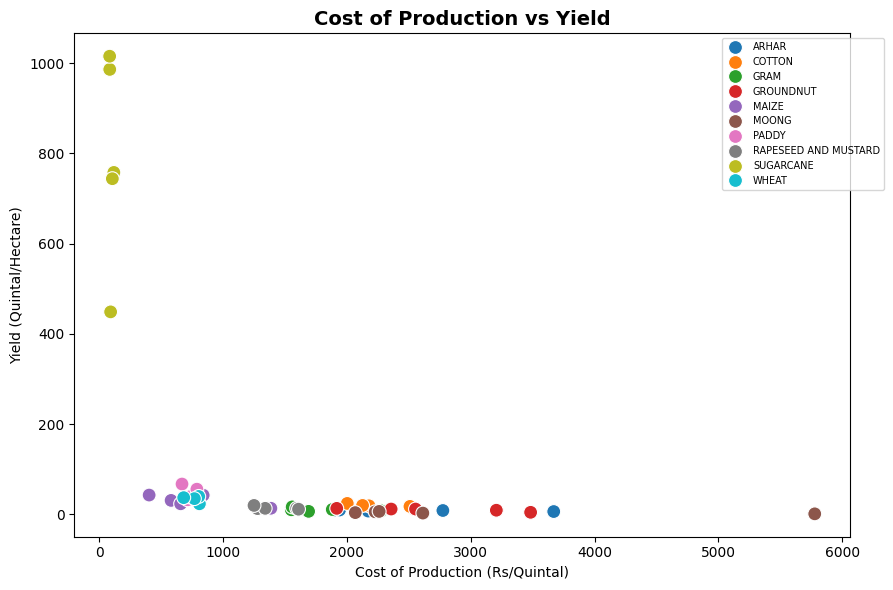

In [9]:

plt.figure(figsize=(9, 6))
sns.scatterplot(x='Cost of Production (`/Quintal) C2',
                y='Yield (Quintal/ Hectare)',
                hue='Crop',
                data=df1,
                s=100)
plt.title('Cost of Production vs Yield', fontsize=14, fontweight='bold')
plt.xlabel('Cost of Production (Rs/Quintal)')
plt.ylabel('Yield (Quintal/Hectare)')
plt.legend(bbox_to_anchor=(1.05, 1), fontsize=7)
plt.tight_layout()
plt.savefig('plot3_cost_yield.png', dpi=150)
plt.show()


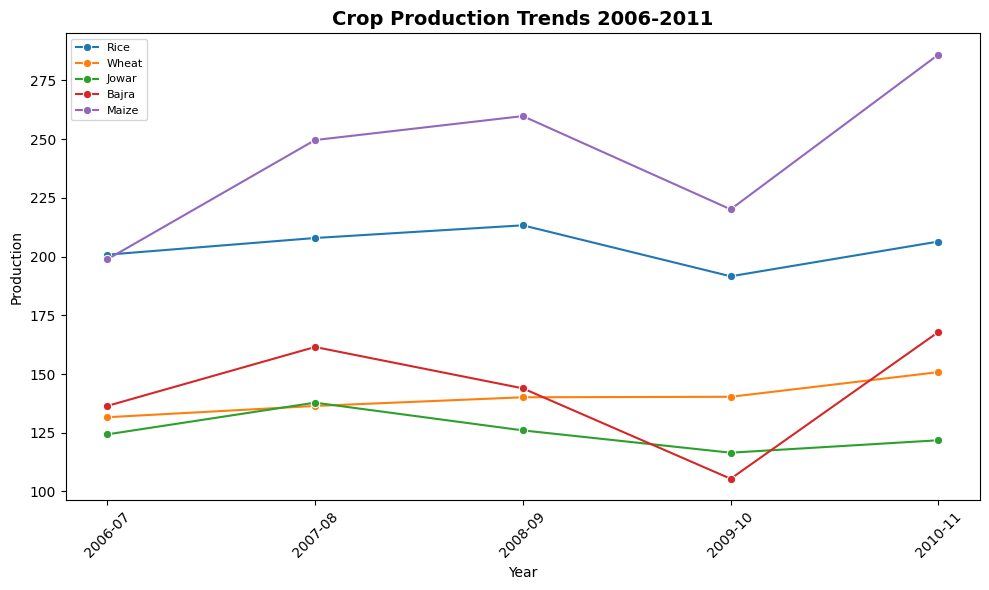

In [10]:
prod_cols = [c for c in df2.columns if 'Production' in c]
df2_plot  = df2[df2['Crop'].str.strip() != 'Total Foodgrains']\
              .head(5).set_index('Crop')[prod_cols].T
df2_plot.index = ['2006-07','2007-08','2008-09','2009-10','2010-11']

plt.figure(figsize=(10, 6))
for col in df2_plot.columns:
    sns.lineplot(x=df2_plot.index, y=df2_plot[col], 
                 marker='o', label=col)
plt.title('Crop Production Trends 2006-2011', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Production')
plt.xticks(rotation=45)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('plot4_trends.png', dpi=150)
plt.show()


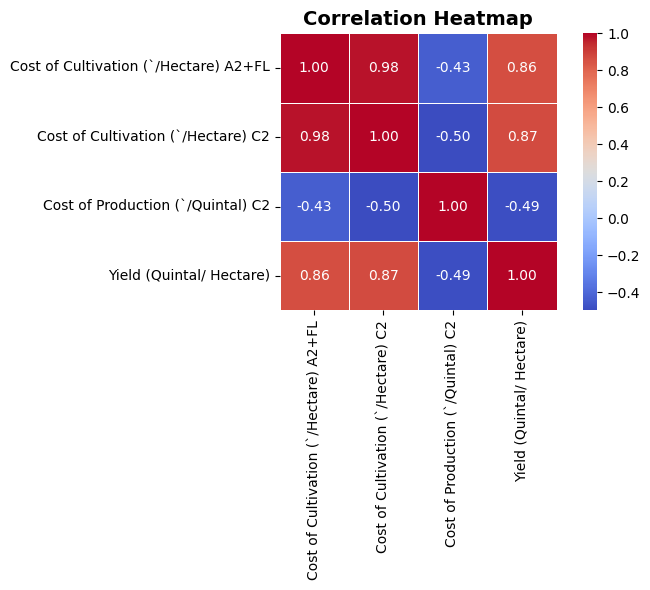

In [11]:
### Cell 3E — Plot 5: Correlation Heatmap (Bonus! 🔥)

plt.figure(figsize=(8, 6))
numeric_cols = df1.select_dtypes(include='number')
sns.heatmap(numeric_cols.corr(), 
            annot=True, 
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            square=True)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot5_heatmap.png', dpi=150)
plt.show()

In [12]:
#Cell 4 — Prepare Features
from sklearn.preprocessing import LabelEncoder

df_ml = df1.copy()
df_ml.rename(columns={
    'Yield (Quintal/ Hectare)'              : 'Yield',
    'Cost of Cultivation (`/Hectare) A2+FL' : 'Cost_A2FL',
    'Cost of Cultivation (`/Hectare) C2'    : 'Cost_C2',
    'Cost of Production (`/Quintal) C2'     : 'CostProd_C2'
}, inplace=True)

le_crop  = LabelEncoder()
le_state = LabelEncoder()
df_ml['Crop_enc']  = le_crop.fit_transform(df_ml['Crop'])
df_ml['State_enc'] = le_state.fit_transform(df_ml['State'])

X = df_ml[['Crop_enc', 'State_enc', 'Cost_A2FL', 'Cost_C2', 'CostProd_C2']]
y = df_ml['Yield']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f" Features ready!")
print(f"   Train : {X_train.shape[0]} rows")
print(f"   Test  : {X_test.shape[0]} rows")

 Features ready!
   Train : 39 rows
   Test  : 10 rows


In [13]:
#Cell 5 — Train Both Models
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, r2_score

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)



print("=" * 40)
print(" MODEL RESULTS")
print("=" * 40)
print(f"\n Linear Regression:")
print(f"   MAE : {mean_absolute_error(y_test, lr_pred):.4f}")
print(f"   R²  : {r2_score(y_test, lr_pred):.4f}")




 MODEL RESULTS

 Linear Regression:
   MAE : 116.7596
   R²  : 0.7800


In [14]:
from sklearn.ensemble import RandomForestRegressor
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("=" * 40)
print(" MODEL RESULTS")
print("=" * 40)

print(f" Random Forest:")
print(f"   MAE : {mean_absolute_error(y_test, rf_pred):.4f}")
print(f"   R²  : {r2_score(y_test, rf_pred):.4f}")

 MODEL RESULTS
 Random Forest:
   MAE : 28.4419
   R²  : 0.9463


In [15]:
winner = "Random Forest" if r2_score(y_test, rf_pred) > r2_score(y_test, lr_pred) else "Linear Regression"
print(f"\n Best Model: {winner}")


 Best Model: Random Forest


#### Result Plots

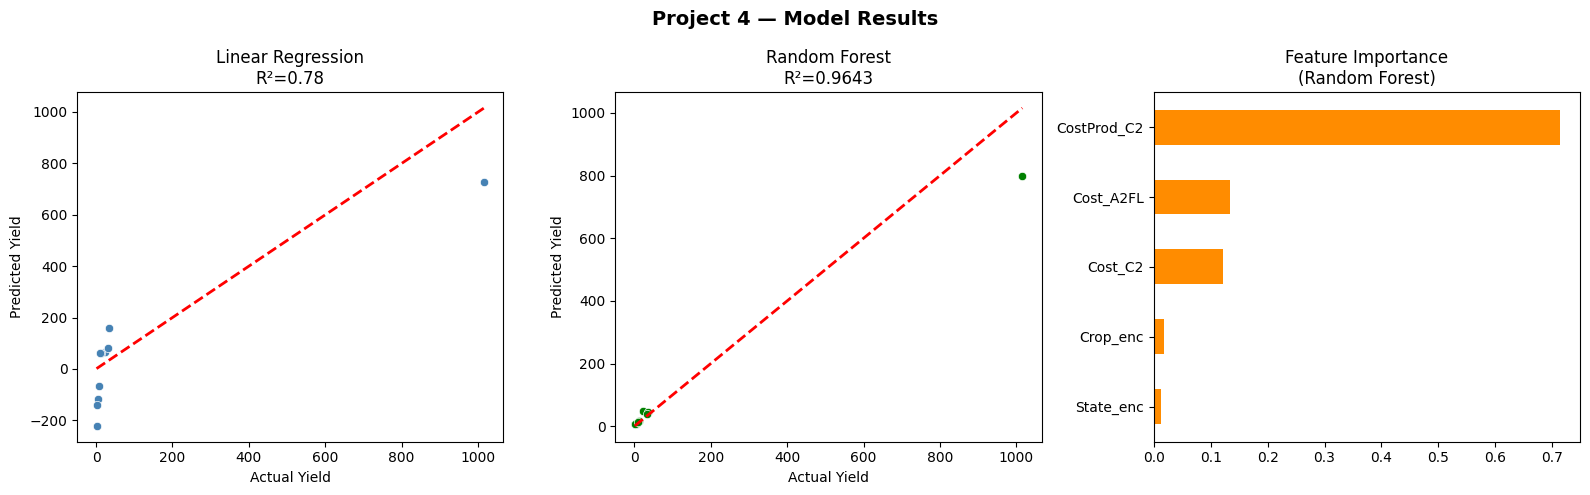

 Result plots saved!


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Project 4 — Model Results', 
             fontsize=14, fontweight='bold')

# Plot 1 — Actual vs Predicted LR
sns.scatterplot(x=y_test, y=lr_pred, ax=axes[0], color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0].set_title(f'Linear Regression\nR²=0.78')
axes[0].set_xlabel('Actual Yield')
axes[0].set_ylabel('Predicted Yield')

# Plot 2 — Actual vs Predicted RF
sns.scatterplot(x=y_test, y=rf_pred, ax=axes[1], color='green')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[1].set_title(f'Random Forest\nR²=0.9643')
axes[1].set_xlabel('Actual Yield')
axes[1].set_ylabel('Predicted Yield')

# Plot 3 — Feature Importance
importances = pd.Series(rf.feature_importances_,
                        index=X.columns).sort_values()
importances.plot(kind='barh', ax=axes[2], color='darkorange')
axes[2].set_title('Feature Importance\n(Random Forest)')

plt.tight_layout()
plt.savefig('model_results.png', dpi=150)
plt.show()
print(" Result plots saved!")

##### Predict New Crop

In [22]:


print("🌾 Sample Prediction:\n")

sample = pd.DataFrame({
    'Crop_enc'    : [le_crop.transform(['ARHAR'])[0]],
    'State_enc'   : [le_state.transform(['Uttar Pradesh'])[0]],
    'Cost_A2FL'   : [9794.05],
    'Cost_C2'     : [23076.74],
    'CostProd_C2' : [1941.55]
})

print(f"   Crop           : ARHAR")
print(f"   State          : Uttar Pradesh")
print(f"   Linear Reg     : {lr.predict(sample)[0]:.2f} Quintal/Hectare")
print(f"   Random Forest  : {rf.predict(sample)[0]:.2f} Quintal/Hectare")
print(f"   Actual Value   : 9.83 Quintal/Hectare")
print("\n✅ Project 4 Complete!")

🌾 Sample Prediction:

   Crop           : ARHAR
   State          : Uttar Pradesh
   Linear Reg     : -54.58 Quintal/Hectare
   Random Forest  : 9.82 Quintal/Hectare
   Actual Value   : 9.83 Quintal/Hectare

✅ Project 4 Complete!
